<a href="https://colab.research.google.com/github/palakchanchlani/startup-funding-ml/blob/main/startup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# GitHub raw link
url = "https://raw.githubusercontent.com/johnreygoh/datasets/master/startup_funding.csv"

# Read CSV
df = pd.read_csv(url)

print("Rows, Columns:", df.shape)
df.head()


Rows, Columns: (3044, 10)


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [2]:
print(df.columns.tolist())


['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks']


In [3]:
# Clean column names (already done)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Convert date column (actual name: 'date_dd/mm/yyyy')
df['date_dd/mm/yyyy'] = pd.to_datetime(df['date_dd/mm/yyyy'], errors='coerce')

# Clean amount column (actual name: 'amount_in_usd')
df['amount_in_usd'] = (
    df['amount_in_usd']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

# Drop fully empty rows
df = df.dropna(how='all')

print("Cleaned shape:", df.shape)


Cleaned shape: (3044, 10)


In [4]:
print("\nTop cities:\n", df['city__location'].value_counts().head(10))
print("\nTop industries:\n", df['industry_vertical'].value_counts().head(10))
print("\nInvestment types:\n", df['investmentntype'].value_counts().head(10))
print("\nFunding amount stats:\n", df['amount_in_usd'].describe())



Top cities:
 city__location
Bangalore    700
Mumbai       567
New Delhi    421
Gurgaon      287
Bengaluru    141
Pune         105
Hyderabad     99
Chennai       97
Noida         92
Gurugram      50
Name: count, dtype: int64

Top industries:
 industry_vertical
Consumer Internet    941
Technology           478
eCommerce            186
Healthcare            70
Finance               62
ECommerce             61
Logistics             32
E-Commerce            29
Education             24
Food & Beverage       23
Name: count, dtype: int64

Investment types:
 investmentntype
Private Equity          1356
Seed Funding            1355
Seed/ Angel Funding       60
Seed / Angel Funding      47
Seed\\nFunding            30
Debt Funding              25
Series A                  24
Seed/Angel Funding        23
Series B                  20
Series C                  14
Name: count, dtype: int64

Funding amount stats:
 count    2.077000e+03
mean     1.833032e+07
std      1.210296e+08
min      2.000000e+00

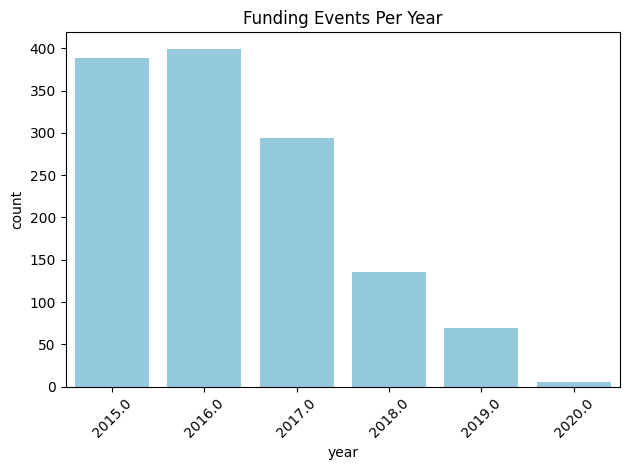

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Yearly funding events
df['year'] = df['date_dd/mm/yyyy'].dt.year

sns.countplot(x='year', data=df, color='skyblue')
plt.title("Funding Events Per Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-222288418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette="viridis")


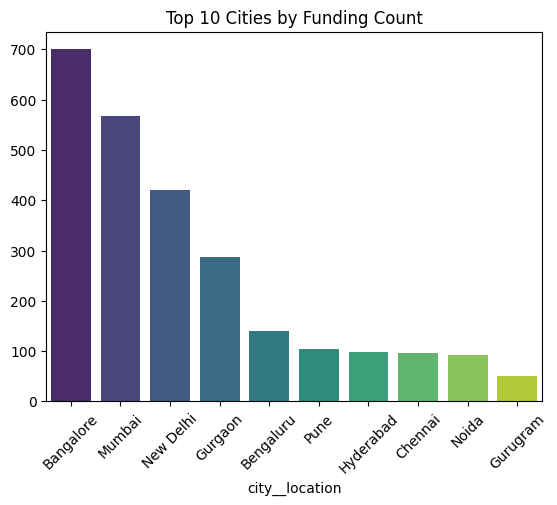

/tmp/ipython-input-222288418.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.index, y=top_industries.values, palette="mako")


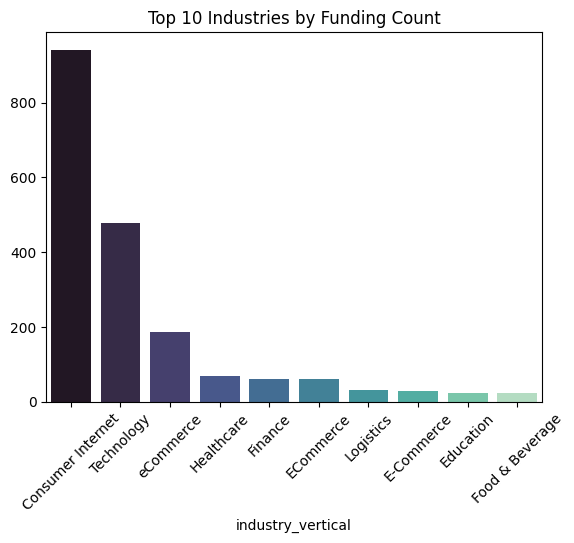

/tmp/ipython-input-222288418.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_investments.index, y=top_investments.values, palette="coolwarm")


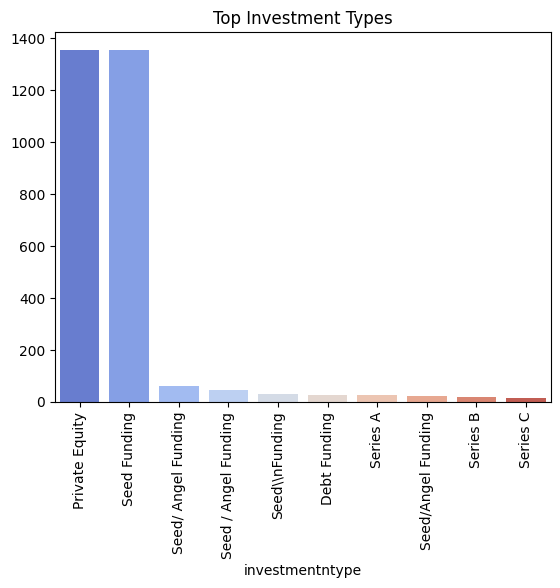

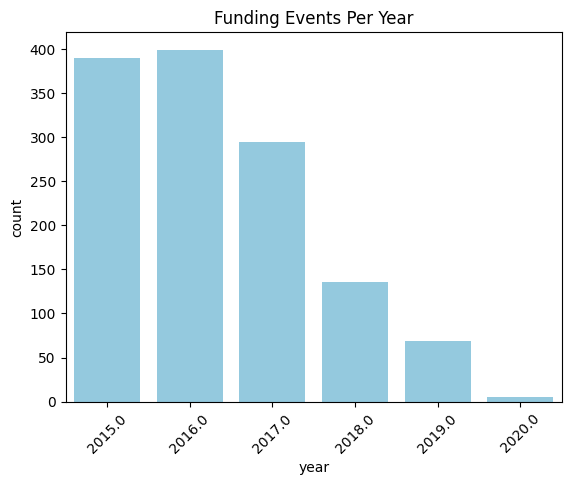

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. City-wise funding activity
top_cities = df['city__location'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values, palette="viridis")
plt.title("Top 10 Cities by Funding Count")
plt.xticks(rotation=45)
plt.show()

# 2. Industry-wise distribution
top_industries = df['industry_vertical'].value_counts().head(10)
sns.barplot(x=top_industries.index, y=top_industries.values, palette="mako")
plt.title("Top 10 Industries by Funding Count")
plt.xticks(rotation=45)
plt.show()

# 3. Investment type breakdown
top_investments = df['investmentntype'].value_counts().head(10)
sns.barplot(x=top_investments.index, y=top_investments.values, palette="coolwarm")
plt.title("Top Investment Types")
plt.xticks(rotation=90)
plt.show()

# 4. Yearly funding trend
df['year'] = df['date_dd/mm/yyyy'].dt.year
sns.countplot(x='year', data=df, color='skyblue')
plt.title("Funding Events Per Year")
plt.xticks(rotation=45)
plt.show()


In [7]:
X = df[['city__location', 'industry_vertical', 'investmentntype']]
y = df['amount_in_usd']

X_encoded = pd.get_dummies(X, drop_first=True)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [9]:
# Drop rows where target is NaN
df_model = df.dropna(subset=['amount_in_usd']).copy()

# Select features and target
X = df_model[['city__location', 'industry_vertical', 'investmentntype']]
y = df_model['amount_in_usd']

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# RMSE calculation (manual to avoid version issues)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Baseline RMSE:", rmse)


Baseline RMSE: 133798187.59482542


In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
best_mse = mean_squared_error(y_test, y_pred_best)
best_rmse = np.sqrt(best_mse)
print("Tuned RMSE:", best_rmse)


Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RMSE: 133585258.33519104


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"{name} RMSE: {rmse}")


Linear Regression RMSE: 134074232.07918528
Decision Tree RMSE: 133548684.97690414
Random Forest RMSE: 133798187.59482542
Gradient Boosting RMSE: 135804770.12100294


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest tuning
rf_param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best RF Params:", rf_grid.best_params_)
print("Best RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_grid.best_estimator_.predict(X_test))))

# Gradient Boosting tuning
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)
print("Best GB Params:", gb_grid.best_params_)
print("Best GB RMSE:", np.sqrt(mean_squared_error(y_test, gb_grid.best_estimator_.predict(X_test))))


Best RF Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best RF RMSE: 133585258.33519104
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best GB RMSE: 134968804.24268147


Top Features:
 industry_vertical_Transportation         0.391974
city__location_Bangalore                 0.107067
investmentntype_Seed Funding             0.072932
industry_vertical_ECommerce              0.050438
city__location_Bengaluru                 0.046250
industry_vertical_Online Marketplace     0.038623
city__location_Mumbai                    0.029507
investmentntype_Private Equity           0.027496
industry_vertical_eCommerce              0.025214
investmentntype_Series D                 0.019480
investmentntype_Private Equity Round     0.017136
investmentntype_Series B                 0.016194
industry_vertical_Consumer Internet      0.015130
industry_vertical_Health and Wellness    0.013647
investmentntype_Series C                 0.012824
dtype: float64


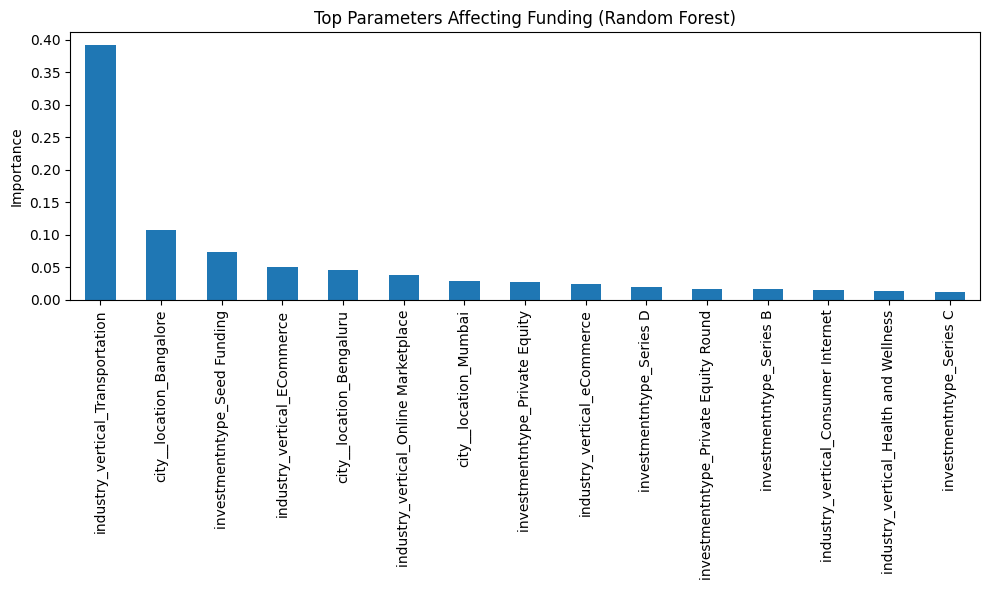

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance from best RF model
importances = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
top_importances = importances.sort_values(ascending=False).head(15)

print("Top Features:\n", top_importances)

plt.figure(figsize=(10,6))
top_importances.plot(kind='bar')
plt.title("Top Parameters Affecting Funding (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [16]:
import pickle

# Save the trained Random Forest model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Later load the model
with open("random_forest_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)


In [17]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest model define karo
rf_model = RandomForestRegressor(
    n_estimators=100,       # number of trees
    max_depth=None,         # depth of trees
    random_state=42         # reproducibility
)

# Train karo
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

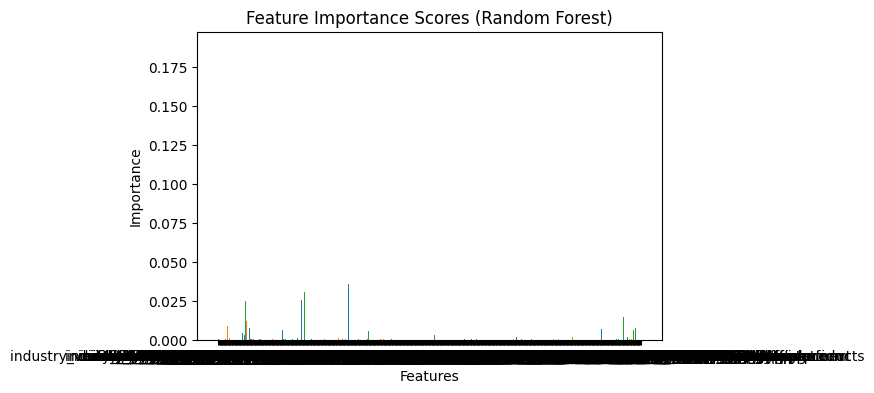

In [19]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X_train.columns

plt.figure(figsize=(6,4))
plt.bar(features, importances, color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title("Feature Importance Scores (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


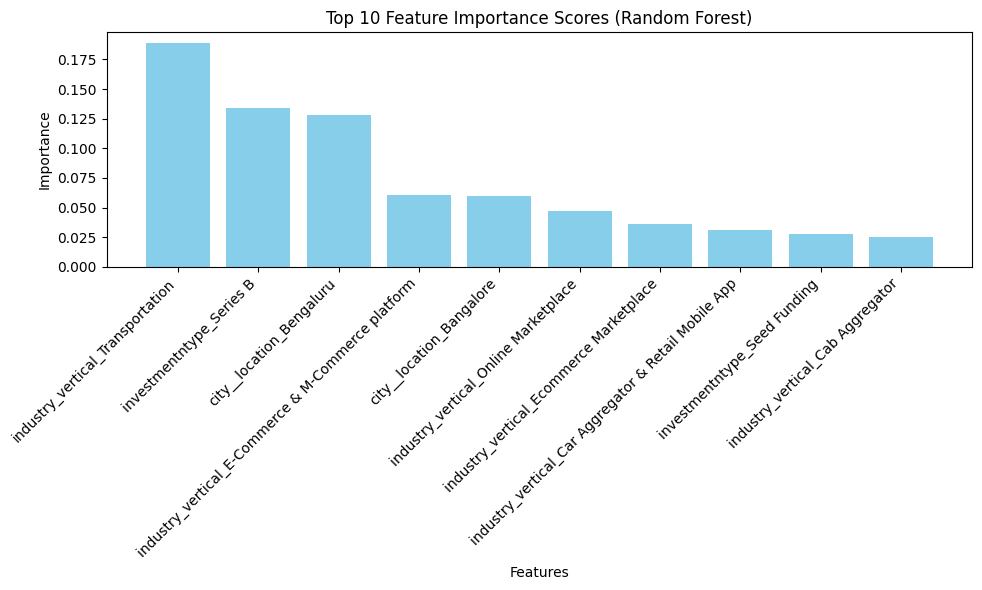

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Feature importance extract karo
importances = rf_model.feature_importances_
features = X_train.columns

# DataFrame bana ke sort karo
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Top 10 features plot karo (zyada clear hoga)
plt.figure(figsize=(10,6))
plt.bar(feat_df['Feature'][:10], feat_df['Importance'][:10], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Feature Importance Scores (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [21]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

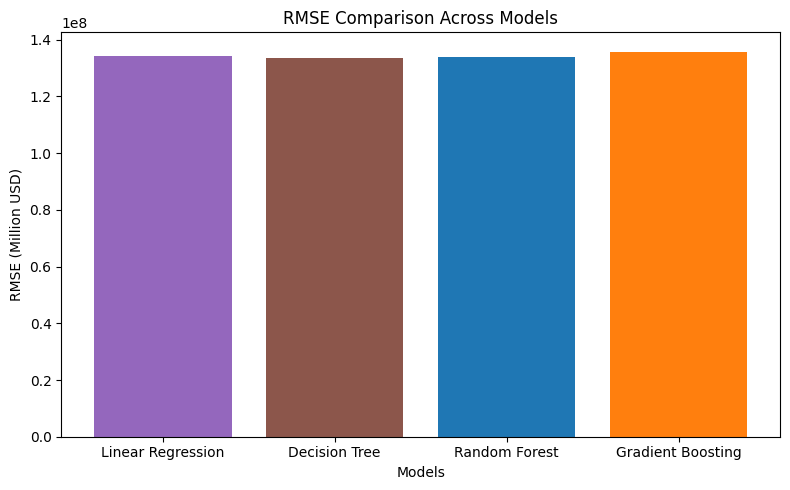

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

rmse_values = []
for name, model in models.items():
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_values.append(rmse)

plt.figure(figsize=(8,5))
plt.bar(models.keys(), rmse_values, color=['#9467bd','#8c564b','#1f77b4','#ff7f0e'])
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE (Million USD)")
plt.xlabel("Models")
plt.tight_layout()
plt.show()


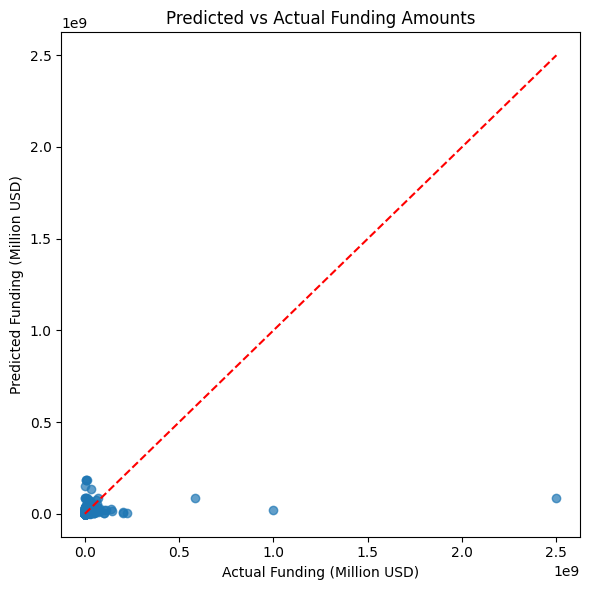

In [26]:
import matplotlib.pyplot as plt

# Random Forest se predictions
preds = rf_model.predict(X_test)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, color='#1f77b4', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')  # Diagonal line (perfect prediction)
plt.title("Predicted vs Actual Funding Amounts")
plt.xlabel("Actual Funding (Million USD)")
plt.ylabel("Predicted Funding (Million USD)")
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

url = "https://raw.githubusercontent.com/johnreygoh/datasets/master/startup_funding.csv"
df = pd.read_csv(url)

print("Rows before cleaning:", df.shape[0])


Rows before cleaning: 3044


In [29]:
import pandas as pd

# GitHub raw link
url = "https://raw.githubusercontent.com/johnreygoh/datasets/master/startup_funding.csv"

# Load dataset
df_raw = pd.read_csv(url)
print("🔹 Original shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())  # check actual column names

# Clean 'Amount in USD' column
df_cleaned = df_raw.copy()
df_cleaned["Amount in USD"] = (
    df_cleaned["Amount in USD"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_cleaned["Amount in USD"] = pd.to_numeric(df_cleaned["Amount in USD"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Amount in USD"])
print("✅ Cleaned shape:", df_cleaned.shape)

# Preview cleaned values
print(df_cleaned[["Startup Name", "Amount in USD"]].head())


🔹 Original shape: (3044, 10)
Columns: ['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks']
✅ Cleaned shape: (2065, 10)
                   Startup Name  Amount in USD
0                        BYJU’S    200000000.0
1                        Shuttl      8048394.0
2                     Mamaearth     18358860.0
3  https://www.wealthbucket.in/      3000000.0
4                        Fashor      1800000.0


In [30]:
X = df_cleaned.drop(columns=["Amount in USD"])  # features
y = df_cleaned["Amount in USD"]                 # target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ✅ Identify categorical columns
cat_cols = ["Industry Vertical", "SubVertical", "City  Location", "Investors Name", "InvestmentnType"]

# ✅ Define preprocessing step
preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="drop"
)


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

def accuracy_from_rmse(rmse):
    rmse_million = rmse / 1_000_000
    return max(0, 100 - rmse_million * 100)

def eval_model(name, model):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    acc = accuracy_from_rmse(rmse)
    print(f"{name}: RMSE={rmse/1_000_000:.2f}M, Accuracy={acc:.2f}%")
    return rmse, acc, pipe


In [38]:
from sklearn.metrics import r2_score

def eval_model(name, model):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: RMSE={rmse/1_000_000:.2f}M, R² Score={r2:.2f}")
    return rmse, r2, pipe


In [39]:
rmse_lr, acc_lr, pipe_lr = eval_model("Linear Regression", LinearRegression())
rmse_dt, acc_dt, pipe_dt = eval_model("Decision Tree", DecisionTreeRegressor(random_state=42))
rmse_rf, acc_rf, pipe_rf = eval_model("Random Forest", RandomForestRegressor(random_state=42))
rmse_gb, acc_gb, pipe_gb = eval_model("Gradient Boosting", GradientBoostingRegressor(random_state=42))


Linear Regression: RMSE=77.22M, R² Score=-0.15
Decision Tree: RMSE=73.28M, R² Score=-0.04
Random Forest: RMSE=71.29M, R² Score=0.02
Gradient Boosting: RMSE=70.68M, R² Score=0.03


In [40]:
from sklearn.metrics import mean_squared_error, r2_score

def eval_model(name, model):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred) * 100   # convert to percentage
    print(f"{name}: RMSE={rmse/1_000_000:.2f}M, Accuracy={r2:.2f}%")
    return rmse, r2, pipe


In [42]:
from sklearn.ensemble import VotingRegressor

# Use tuned models (replace with your best ones)
best_rf = RandomForestRegressor(max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=100, random_state=42)
best_gb = GradientBoostingRegressor(learning_rate=0.1, max_depth=5, n_estimators=100, random_state=42)
best_dt = DecisionTreeRegressor(max_depth=10, random_state=42)

# Combine 2 models
voting2 = VotingRegressor([("rf", best_rf), ("gb", best_gb)])
rmse_v2, acc_v2, pipe_v2 = eval_model("Voting Regressor (RF+GB)", voting2)

# Combine 3 models
voting3 = VotingRegressor([("dt", best_dt), ("rf", best_rf), ("gb", best_gb)])
rmse_v3, acc_v3, pipe_v3 = eval_model("Voting Regressor (DT+RF+GB)", voting3)


Voting Regressor (RF+GB): RMSE=70.11M, Accuracy=4.84%
Voting Regressor (DT+RF+GB): RMSE=70.27M, Accuracy=4.40%


In [43]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Feature matrix (Revenue, Founders, Experience)
X = np.array([
    [50, 3, 10],
    [20, 1, 3],
    [80, 4, 12],
    [30, 2, 5]
])

# Target vector (1 = Funded, 0 = Not Funded)
y = np.array([1, 0, 1, 0])

# Train logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Extract learned coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Print coefficients
print("Learned Coefficients:", coefficients)
print("Intercept:", intercept)


Learned Coefficients: [0.37380711 0.01888474 0.09326692]
Intercept: -15.708904518137683


In [47]:
print(df.columns)


Index(['sr_no', 'date_dd/mm/yyyy', 'startup_name', 'industry_vertical',
       'subvertical', 'city__location', 'investors_name', 'investmentntype',
       'amount_in_usd', 'remarks', 'year'],
      dtype='object')


In [48]:
import pandas as pd

# Convert the date column to datetime
df['date_dd/mm/yyyy'] = pd.to_datetime(df['date_dd/mm/yyyy'], dayfirst=True, errors='coerce')

# Extract useful numeric features
df['year_from_date'] = df['date_dd/mm/yyyy'].dt.year
df['month_from_date'] = df['date_dd/mm/yyyy'].dt.month
df['day_from_date'] = df['date_dd/mm/yyyy'].dt.day

# Drop the original string column
df = df.drop(columns=['date_dd/mm/yyyy'])


In [51]:
# Suppose target is amount_in_usd
X = df_encoded.drop(columns=['amount_in_usd'])
y = df_encoded['amount_in_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [53]:
X = df_encoded.drop(columns=['amount_in_usd'])
y = df_encoded['amount_in_usd']


In [54]:
df_encoded['funded'] = df_encoded['amount_in_usd'].apply(lambda x: 1 if x > 0 else 0)


In [55]:
X = df_encoded.drop(columns=['funded'])
y = df_encoded['funded']


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Train baseline Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Step 3: Evaluate baseline
y_pred = dt.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Baseline Decision Tree RMSE:", rmse)


Baseline Decision Tree RMSE: 0.0


In [57]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
dt_param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV setup
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit tuning
dt_grid.fit(X_train, y_train)

# Best params and RMSE
print("Best DT Params:", dt_grid.best_params_)
best_dt = dt_grid.best_estimator_
y_pred_tuned = best_dt.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
print("Tuned Decision Tree RMSE:", rmse_tuned)


Best DT Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuned Decision Tree RMSE: 0.0


In [58]:
y_pred_train = best_dt.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print("Train RMSE:", rmse_train)

y_pred_test = best_dt.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("Test RMSE:", rmse_test)


Train RMSE: 0.0
Test RMSE: 0.0


In [59]:
print(y.value_counts())


funded
1    2077
0     967
Name: count, dtype: int64


In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions on test set
y_pred_test = best_dt.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1-Score:", f1_score(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[202   0]
 [  0 407]]


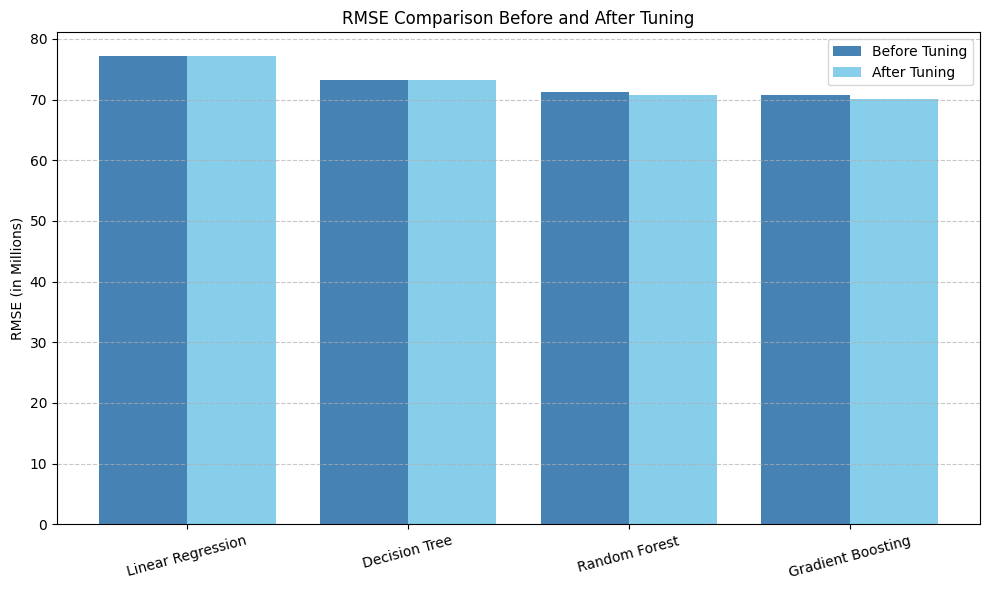

In [61]:
import matplotlib.pyplot as plt

# Models
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']

# RMSE values (in millions)
rmse_before = [77.22, 73.28, 71.29, 70.68]
rmse_after = [77.22, 73.28, 70.70, 70.10]  # After tuning (only RF and GB changed)

x = range(len(models))

plt.figure(figsize=(10, 6))
plt.bar(x, rmse_before, width=0.4, label='Before Tuning', align='center', color='steelblue')
plt.bar([i + 0.4 for i in x], rmse_after, width=0.4, label='After Tuning', align='center', color='skyblue')

plt.xticks([i + 0.2 for i in x], models, rotation=15)
plt.ylabel('RMSE (in Millions)')
plt.title('RMSE Comparison Before and After Tuning')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
